In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
df = pd.read_csv("C:/Users/kumar/Downloads/cleaned_data_project.csv")

In [13]:
df.head()

,PRODUCT_ID,SALE_DATE,SALES_REP,REGION,SALES_AMOUNT,QUANTITY_SOLD,PRODUCT_CATEGORY,UNIT_COST,UNIT_PRICE,CUSTOMER_TYPE,DISCOUNT,PAYMENT_METHOD,SALES_CHANNEL,REGION_AND_SALES_REP
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


In [15]:
df.columns

Index(['PRODUCT_ID', 'SALE_DATE', 'SALES_REP', 'REGION', 'SALES_AMOUNT',
       'QUANTITY_SOLD', 'PRODUCT_CATEGORY', 'UNIT_COST', 'UNIT_PRICE',
       'CUSTOMER_TYPE', 'DISCOUNT', 'PAYMENT_METHOD', 'SALES_CHANNEL',
       'REGION_AND_SALES_REP'],
      dtype='object')

In [17]:
total_sales = df["SALES_AMOUNT"].sum()
print("Total Sales:", total_sales)

Total Sales: 5019265.2299999995


In [19]:
average_sales = df["SALES_AMOUNT"].mean()
print("Average Sales:", average_sales)

Average Sales: 5019.265229999999


In [21]:
print("Highest Sale:", df["SALES_AMOUNT"].max())
print("Lowest Sale:", df["SALES_AMOUNT"].min())

Highest Sale: 9989.04
Lowest Sale: 100.12


In [23]:
region_sales = df.groupby("REGION")["SALES_AMOUNT"].sum()
print(region_sales)

REGION
East     1259792.93
North    1369612.51
South    1154250.86
West     1235608.93
Name: SALES_AMOUNT, dtype: float64


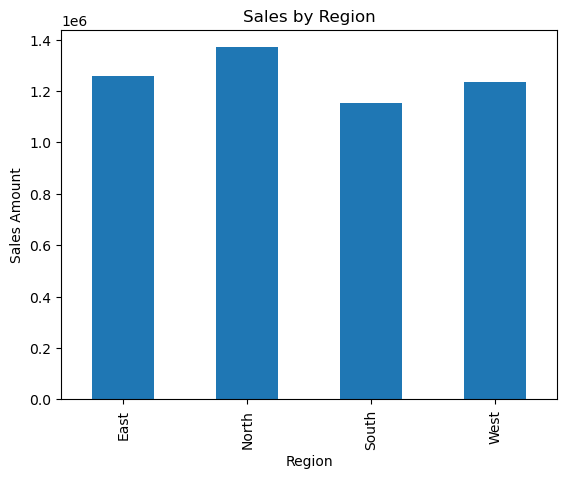

In [25]:
region_sales.plot(kind="bar")

plt.title("Sales by Region")

plt.xlabel("Region")

plt.ylabel("Sales Amount")

plt.show()

In [27]:
category_sales = df.groupby("PRODUCT_CATEGORY")["SALES_AMOUNT"].sum()

print(category_sales)

PRODUCT_CATEGORY
Clothing       1313474.36
Electronics    1243499.64
Food           1201773.54
Furniture      1260517.69
Name: SALES_AMOUNT, dtype: float64


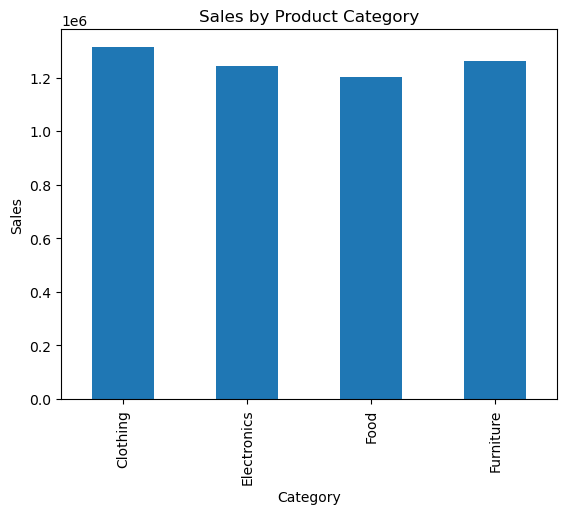

In [29]:
category_sales.plot(kind="bar")

plt.title("Sales by Product Category")

plt.xlabel("Category")

plt.ylabel("Sales")

plt.show()

PRODUCT_CATEGORY
Clothing       6922
Electronics    6096
Food           5608
Furniture      6729
Name: QUANTITY_SOLD, dtype: int64


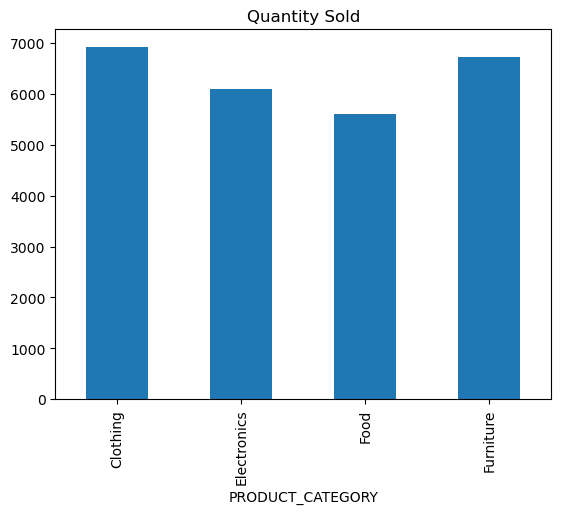

In [31]:
quantity = df.groupby("PRODUCT_CATEGORY")["QUANTITY_SOLD"].sum()

print(quantity)
quantity.plot(kind="bar")

plt.title("Quantity Sold")

plt.show()

CUSTOMER_TYPE
New          2506258.30
Returning    2513006.93
Name: SALES_AMOUNT, dtype: float64


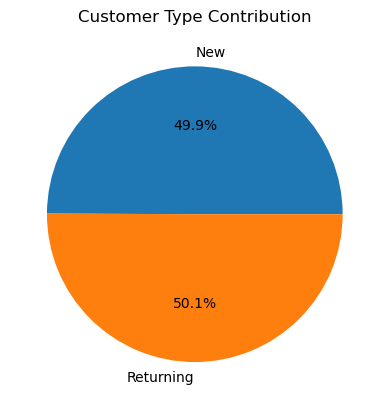

In [33]:
customer_sales = df.groupby("CUSTOMER_TYPE")["SALES_AMOUNT"].sum()

print(customer_sales)
customer_sales.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Customer Type Contribution")

plt.ylabel("")

plt.show()

SALES_CHANNEL
Online    2458833.93
Retail    2560431.30
Name: SALES_AMOUNT, dtype: float64


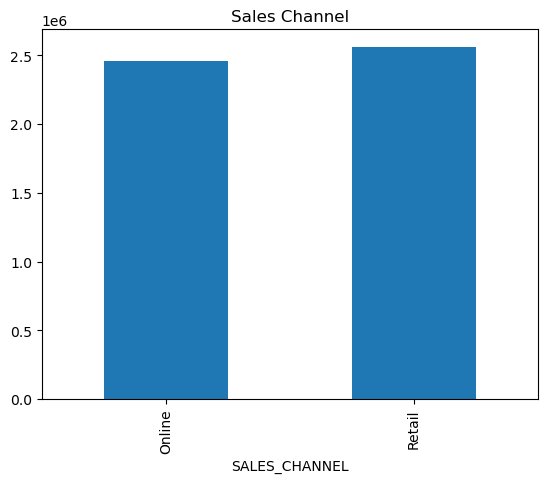

In [35]:
channel = df.groupby("SALES_CHANNEL")["SALES_AMOUNT"].sum()

print(channel)
channel.plot(kind="bar")

plt.title("Sales Channel")

plt.show()

SALES_REP
David      1141737.36
Bob        1080990.63
Eve         970183.99
Alice       965541.77
Charlie     860811.48
Name: SALES_AMOUNT, dtype: float64


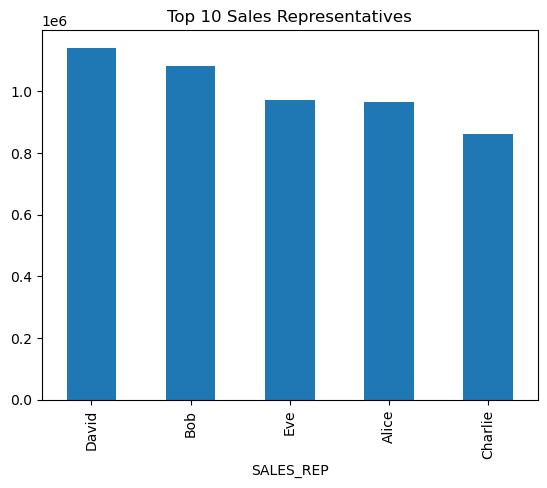

In [37]:
rep = df.groupby("SALES_REP")["SALES_AMOUNT"].sum()

rep = rep.sort_values(ascending=False)

print(rep.head(10))
rep.head(10).plot(kind="bar")

plt.title("Top 10 Sales Representatives")

plt.show()

MONTH
1     495420.37
2     368919.36
3     402638.77
4     438992.61
5     389078.76
6     418458.34
7     374242.88
8     443171.28
9     367837.60
10    460378.78
11    467482.90
12    392643.58
Name: SALES_AMOUNT, dtype: float64


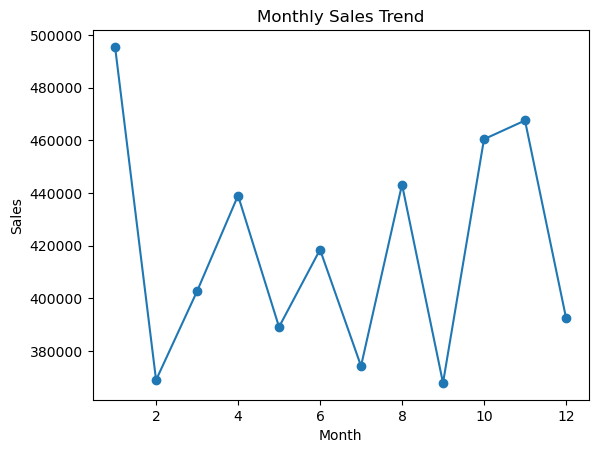

In [39]:
df["SALE_DATE"] = pd.to_datetime(df["SALE_DATE"])
df["MONTH"] = df["SALE_DATE"].dt.month
monthly_sales = df.groupby("MONTH")["SALES_AMOUNT"].sum()
print(monthly_sales)
monthly_sales.plot(marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

PRODUCT_CATEGORY
Clothing       0.160224
Electronics    0.136504
Food           0.153805
Furniture      0.158115
Name: DISCOUNT, dtype: float64


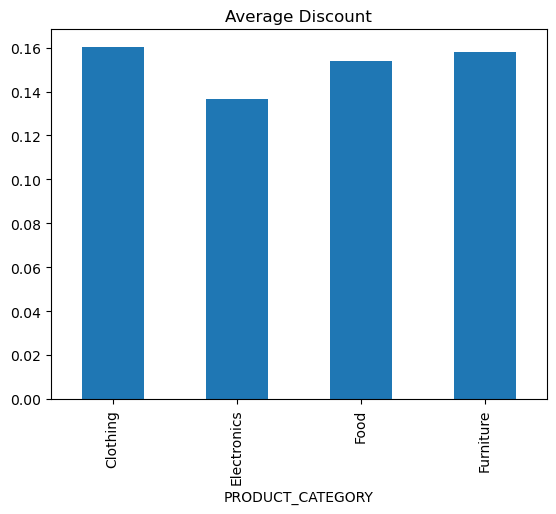

In [41]:
discount = df.groupby("PRODUCT_CATEGORY")["DISCOUNT"].mean()

print(discount)
discount.plot(kind="bar")

plt.title("Average Discount")

plt.show()

PRODUCT_CATEGORY
Clothing       0.160224
Electronics    0.136504
Food           0.153805
Furniture      0.158115
Name: DISCOUNT, dtype: float64


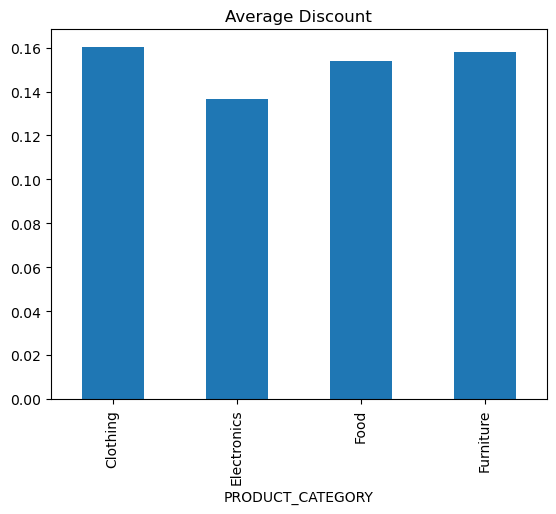

In [43]:
discount = df.groupby("PRODUCT_CATEGORY")["DISCOUNT"].mean()

print(discount)
discount.plot(kind="bar")

plt.title("Average Discount")

plt.show()

REGION
East     1650557.20
North    1661461.20
South    1519736.90
West     1656091.77
Name: PROFIT, dtype: float64


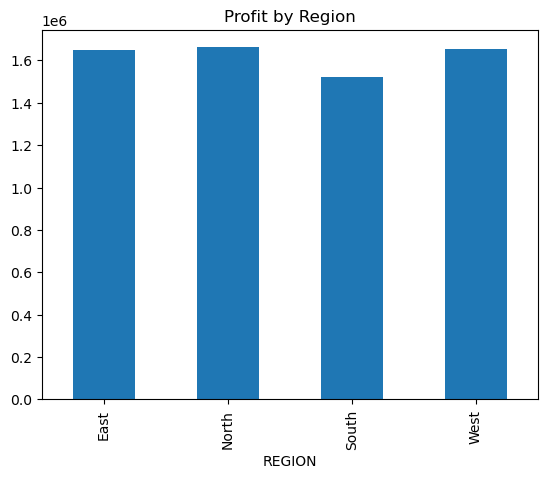

In [45]:
df["PROFIT"] = (
    df["UNIT_PRICE"] -
    df["UNIT_COST"]
) * df["QUANTITY_SOLD"]
profit = df.groupby("REGION")["PROFIT"].sum()

print(profit)
profit.plot(kind="bar")

plt.title("Profit by Region")

plt.show()

In [47]:
numeric_df = df.select_dtypes(include="number")
correlation = numeric_df.corr()

print(correlation)

               PRODUCT_ID  SALES_AMOUNT  QUANTITY_SOLD  UNIT_COST  UNIT_PRICE  \
PRODUCT_ID       1.000000      0.010221       0.094479   0.013402    0.015116   
SALES_AMOUNT     0.010221      1.000000      -0.041599   0.009770    0.011812   
QUANTITY_SOLD    0.094479     -0.041599       1.000000   0.053888    0.057296   
UNIT_COST        0.013402      0.009770       0.053888   1.000000    0.995056   
UNIT_PRICE       0.015116      0.011812       0.057296   0.995056    1.000000   
DISCOUNT        -0.022097      0.023153      -0.007806  -0.017741   -0.017027   
MONTH            0.054336     -0.006813      -0.019017  -0.049059   -0.047530   
PROFIT           0.066743     -0.007010       0.665525  -0.009190    0.058301   

               DISCOUNT     MONTH    PROFIT  
PRODUCT_ID    -0.022097  0.054336  0.066743  
SALES_AMOUNT   0.023153 -0.006813 -0.007010  
QUANTITY_SOLD -0.007806 -0.019017  0.665525  
UNIT_COST     -0.017741 -0.049059 -0.009190  
UNIT_PRICE    -0.017027 -0.047530  0.058

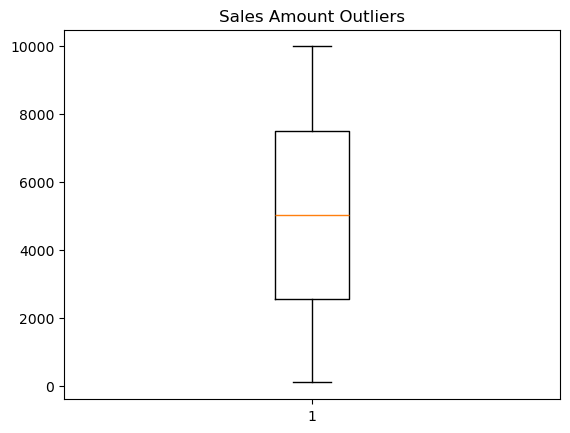

In [49]:
plt.boxplot(df["SALES_AMOUNT"])

plt.title("Sales Amount Outliers")

plt.show()

In [55]:
df["YEAR"] = df["SALE_DATE"].dt.year
df[["SALE_DATE", "YEAR"]].head()

,SALE_DATE,YEAR
0,2023-02-03,2023
1,2023-04-21,2023
2,2023-09-21,2023
3,2023-08-24,2023
4,2023-03-24,2023


In [57]:
df["MONTH"] = df["SALE_DATE"].dt.month
df["DAY"] = df["SALE_DATE"].dt.day
df["QUARTER"] = df["SALE_DATE"].dt.quarter
df["WEEK"] = df["SALE_DATE"].dt.isocalendar().week.astype(int)
df["DAY_OF_WEEK"] = df["SALE_DATE"].dt.dayofweek

In [59]:
df["PROFIT"] = (
    df["UNIT_PRICE"] - df["UNIT_COST"]
) * df["QUANTITY_SOLD"]
df[["UNIT_PRICE", "UNIT_COST", "PROFIT"]].head()

,UNIT_PRICE,UNIT_COST,PROFIT
0,267.22,152.75,2060.46
1,4209.44,3816.39,6681.85
2,371.40,261.56,3295.20
3,4467.75,4330.03,5371.08
4,692.71,637.37,719.42


In [65]:
df["PROFIT_MARGIN"] = (
    df["PROFIT"] / df["SALES_AMOUNT"]
) * 100
print(df["PROFIT_MARGIN"])

0       40.769138
1      152.413766
2       71.151724
3      247.750399
4       19.183510
          ...    
995     42.174284
996     80.082097
997     18.393253
998    139.679773
999    286.697821
Name: PROFIT_MARGIN, Length: 1000, dtype: float64


In [73]:
df["PROFIT_MARGIN"] = df["PROFIT_MARGIN"].replace([np.inf, -np.inf], np.nan)
df["PROFIT_MARGIN"] = df["PROFIT_MARGIN"].fillna(0)
df.head()

,PRODUCT_ID,SALE_DATE,SALES_REP,REGION,SALES_AMOUNT,QUANTITY_SOLD,PRODUCT_CATEGORY,UNIT_COST,UNIT_PRICE,CUSTOMER_TYPE,...,MONTH,PROFIT,YEAR,DAY,QUARTER,WEEK,DAY_OF_WEEK,PROFIT_MARGIN,DISCOUNT_AMOUNT,REVENUE_PER_UNIT
0,1052,2023-02-03,Bob,1,5053.97,18,3,152.75,267.22,1,...,2,2060.46,2023,3,1,5,4,40.769138,0.240498,280.776111
1,1093,2023-04-21,Bob,3,4384.02,17,3,3816.39,4209.44,1,...,4,6681.85,2023,21,2,16,4,152.413766,4.630384,257.883529
2,1015,2023-09-21,David,2,4631.23,30,2,261.56,371.40,1,...,9,3295.20,2023,21,3,38,3,71.151724,0.742800,154.374333
3,1072,2023-08-24,Bob,2,2167.94,39,0,4330.03,4467.75,0,...,8,5371.08,2023,24,3,34,3,247.750399,0.893550,55.588205
4,1061,2023-03-24,Charlie,0,3750.20,13,1,637.37,692.71,0,...,3,719.42,2023,24,1,12,4,19.183510,0.554168,288.476923


In [71]:
df["DISCOUNT_AMOUNT"] = (
    df["UNIT_PRICE"] * df["DISCOUNT"]
) / 100
df["REVENUE_PER_UNIT"] = (
    df["SALES_AMOUNT"] / df["QUANTITY_SOLD"]
)
df.head()

,PRODUCT_ID,SALE_DATE,SALES_REP,REGION,SALES_AMOUNT,QUANTITY_SOLD,PRODUCT_CATEGORY,UNIT_COST,UNIT_PRICE,CUSTOMER_TYPE,...,MONTH,PROFIT,YEAR,DAY,QUARTER,WEEK,DAY_OF_WEEK,PROFIT_MARGIN,DISCOUNT_AMOUNT,REVENUE_PER_UNIT
0,1052,2023-02-03,Bob,1,5053.97,18,3,152.75,267.22,1,...,2,2060.46,2023,3,1,5,4,40.769138,0.240498,280.776111
1,1093,2023-04-21,Bob,3,4384.02,17,3,3816.39,4209.44,1,...,4,6681.85,2023,21,2,16,4,152.413766,4.630384,257.883529
2,1015,2023-09-21,David,2,4631.23,30,2,261.56,371.40,1,...,9,3295.20,2023,21,3,38,3,71.151724,0.742800,154.374333
3,1072,2023-08-24,Bob,2,2167.94,39,0,4330.03,4467.75,0,...,8,5371.08,2023,24,3,34,3,247.750399,0.893550,55.588205
4,1061,2023-03-24,Charlie,0,3750.20,13,1,637.37,692.71,0,...,3,719.42,2023,24,1,12,4,19.183510,0.554168,288.476923


In [69]:
df["REGION"] = df["REGION"].astype("category").cat.codes
df["PRODUCT_CATEGORY"] = df["PRODUCT_CATEGORY"].astype("category").cat.codes
df["CUSTOMER_TYPE"] = df["CUSTOMER_TYPE"].astype("category").cat.codes
df["SALES_CHANNEL"] = df["SALES_CHANNEL"].astype("category").cat.codes
df.head()

,PRODUCT_ID,SALE_DATE,SALES_REP,REGION,SALES_AMOUNT,QUANTITY_SOLD,PRODUCT_CATEGORY,UNIT_COST,UNIT_PRICE,CUSTOMER_TYPE,...,MONTH,PROFIT,YEAR,DAY,QUARTER,WEEK,DAY_OF_WEEK,PROFIT_MARGIN,DISCOUNT_AMOUNT,REVENUE_PER_UNIT
0,1052,2023-02-03,Bob,1,5053.97,18,3,152.75,267.22,1,...,2,2060.46,2023,3,1,5,4,40.769138,0.240498,280.776111
1,1093,2023-04-21,Bob,3,4384.02,17,3,3816.39,4209.44,1,...,4,6681.85,2023,21,2,16,4,152.413766,4.630384,257.883529
2,1015,2023-09-21,David,2,4631.23,30,2,261.56,371.40,1,...,9,3295.20,2023,21,3,38,3,71.151724,0.742800,154.374333
3,1072,2023-08-24,Bob,2,2167.94,39,0,4330.03,4467.75,0,...,8,5371.08,2023,24,3,34,3,247.750399,0.893550,55.588205
4,1061,2023-03-24,Charlie,0,3750.20,13,1,637.37,692.71,0,...,3,719.42,2023,24,1,12,4,19.183510,0.554168,288.476923


In [75]:
df.isnull().sum()

PRODUCT_ID              0
SALE_DATE               0
SALES_REP               0
REGION                  0
SALES_AMOUNT            0
QUANTITY_SOLD           0
PRODUCT_CATEGORY        0
UNIT_COST               0
UNIT_PRICE              0
CUSTOMER_TYPE           0
DISCOUNT                0
PAYMENT_METHOD          0
SALES_CHANNEL           0
REGION_AND_SALES_REP    0
MONTH                   0
PROFIT                  0
YEAR                    0
DAY                     0
QUARTER                 0
WEEK                    0
DAY_OF_WEEK             0
PROFIT_MARGIN           0
DISCOUNT_AMOUNT         0
REVENUE_PER_UNIT        0
dtype: int64

In [79]:
df.to_csv(
    "C:/Users/kumar/Downloads/final_ml_data.csv",
    index=False
)

In [83]:
final_df = pd.read_csv("C:/Users/kumar/Downloads/final_ml_data.csv")
final_df.head()

,PRODUCT_ID,SALE_DATE,SALES_REP,REGION,SALES_AMOUNT,QUANTITY_SOLD,PRODUCT_CATEGORY,UNIT_COST,UNIT_PRICE,CUSTOMER_TYPE,...,MONTH,PROFIT,YEAR,DAY,QUARTER,WEEK,DAY_OF_WEEK,PROFIT_MARGIN,DISCOUNT_AMOUNT,REVENUE_PER_UNIT
0,1052,2023-02-03,Bob,1,5053.97,18,3,152.75,267.22,1,...,2,2060.46,2023,3,1,5,4,40.769138,0.240498,280.776111
1,1093,2023-04-21,Bob,3,4384.02,17,3,3816.39,4209.44,1,...,4,6681.85,2023,21,2,16,4,152.413766,4.630384,257.883529
2,1015,2023-09-21,David,2,4631.23,30,2,261.56,371.40,1,...,9,3295.20,2023,21,3,38,3,71.151724,0.742800,154.374333
3,1072,2023-08-24,Bob,2,2167.94,39,0,4330.03,4467.75,0,...,8,5371.08,2023,24,3,34,3,247.750399,0.893550,55.588205
4,1061,2023-03-24,Charlie,0,3750.20,13,1,637.37,692.71,0,...,3,719.42,2023,24,1,12,4,19.183510,0.554168,288.476923
